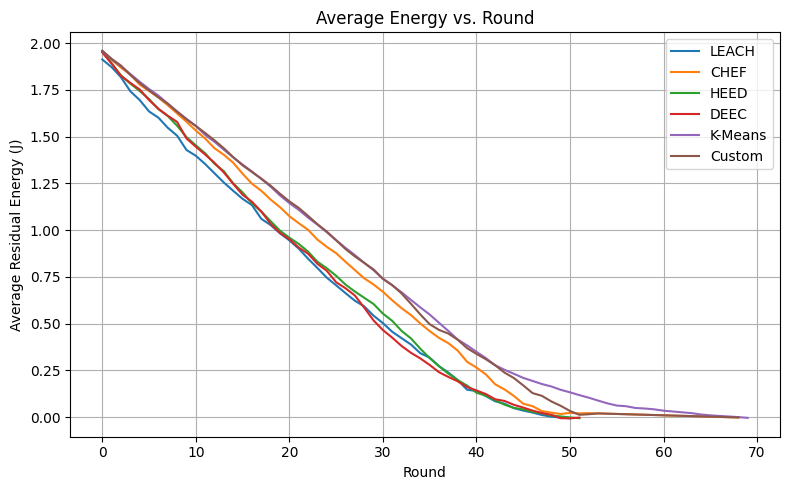

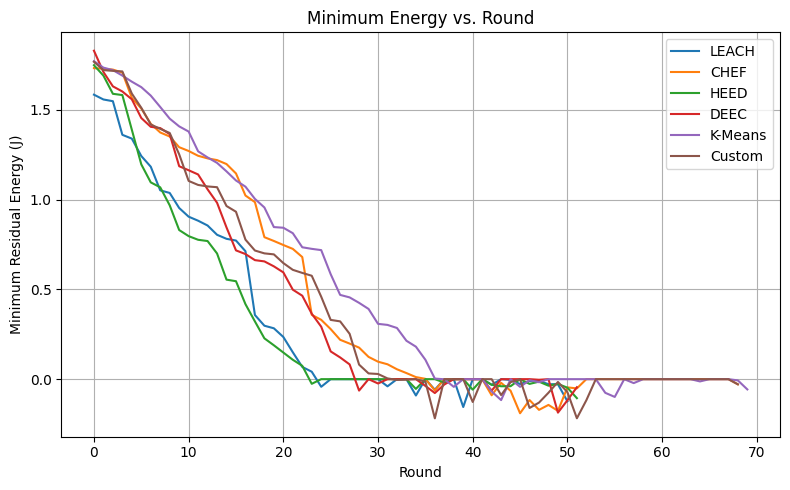

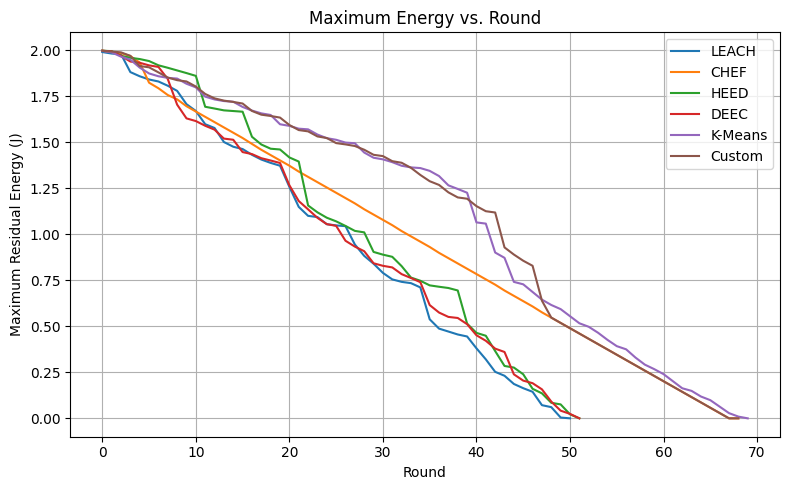

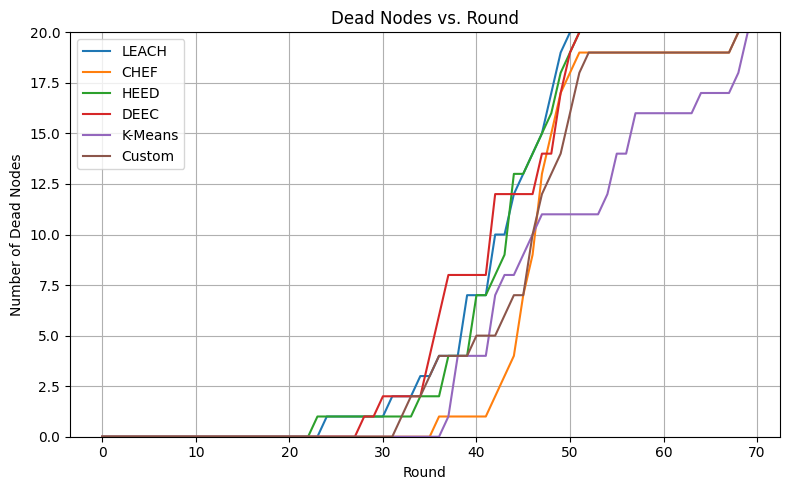

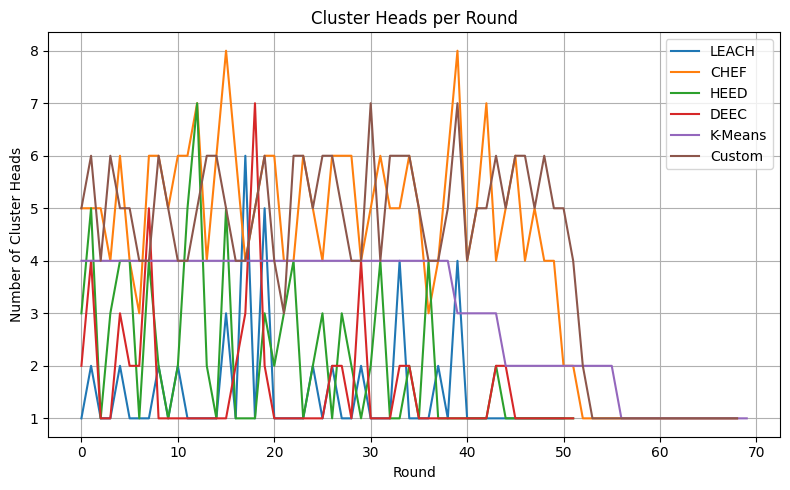

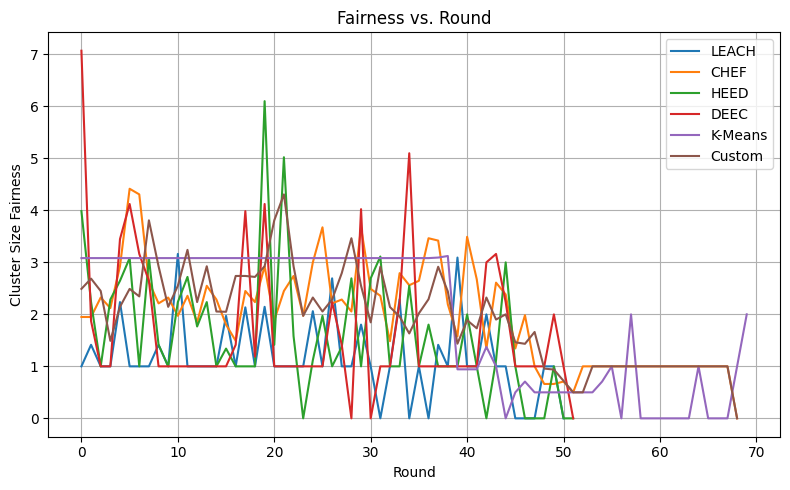

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

algos = ['LEACH', 'CHEF', 'HEED', 'DEEC', 'K-Means', 'Custom']
files = {
    'LEACH': 'leach_log.csv',
    'CHEF': 'chef_log.csv',
    'HEED': 'heed_log.csv',
    'DEEC': 'deec_log.csv',
    'K-Means': 'k-means_log.csv',
    'Custom': 'custom_log.csv'
}

dfs = {algo: pd.read_csv(files[algo]) for algo in algos}

# Plotting function
def plot_metric(metric, ylabel, title, ylim=None):
    plt.figure(figsize=(8,5))
    for algo in algos:
        plt.plot(dfs[algo]['Round'], dfs[algo][metric], label=algo)
    plt.xlabel('Round')
    plt.ylabel(ylabel)
    plt.title(title)
    if ylim:
        plt.ylim(*ylim)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 1. Average Energy
plot_metric('AvgEnergy', 'Average Residual Energy (J)', 'Average Energy vs. Round')

# 2. Minimum Energy
plot_metric('MinEnergy', 'Minimum Residual Energy (J)', 'Minimum Energy vs. Round')

# 3. Maximum Energy
plot_metric('MaxEnergy', 'Maximum Residual Energy (J)', 'Maximum Energy vs. Round')

# 4. Number of Dead Nodes
plot_metric('Dead', 'Number of Dead Nodes', 'Dead Nodes vs. Round', ylim=(0, 20))

# 5. Cluster Head Count
plot_metric('CHs', 'Number of Cluster Heads', 'Cluster Heads per Round')

# 6. Fairness
plot_metric('Fairness', 'Cluster Size Fairness', 'Fairness vs. Round')


  Algorithm  First Node Death  All Nodes Dead  Avg. Cluster Heads  \
0     LEACH                24              50                1.49   
1      CHEF                36              68                4.06   
2      HEED                23              51                2.10   
3      DEEC                28              51                1.60   
4   K-Means                37              69                2.99   
5    Custom                32              68                4.09   

   Avg. Fairness  Avg. Energy  
0           1.17        0.781  
1           1.96        0.667  
2           1.63        0.794  
3           1.70        0.780  
4           1.97        0.714  
5           1.95        0.707  


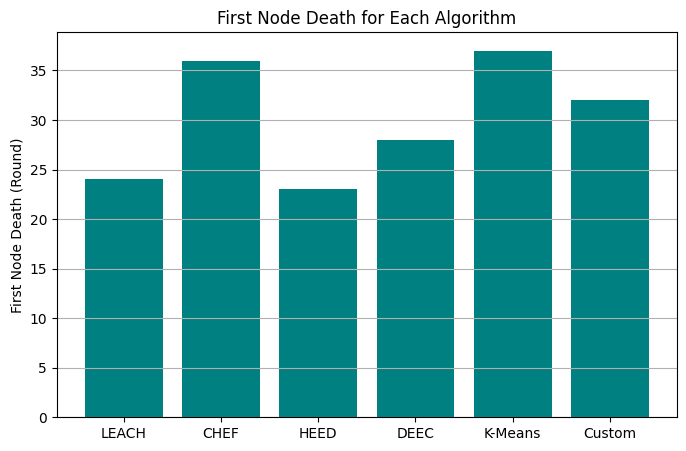

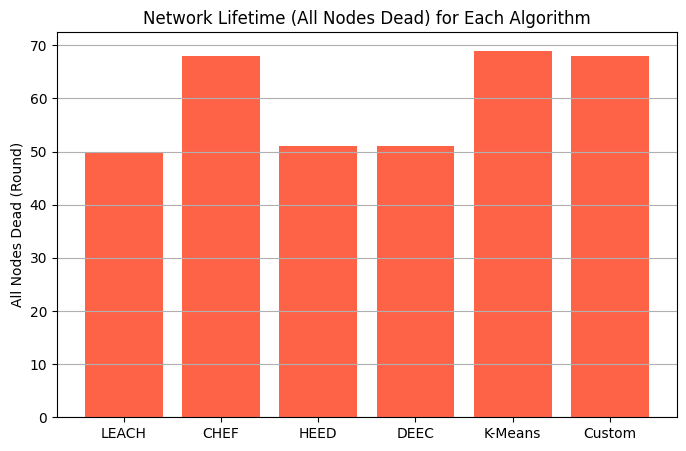

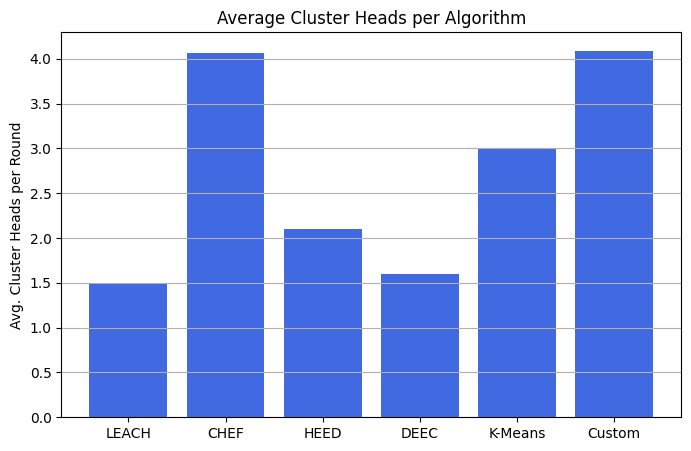

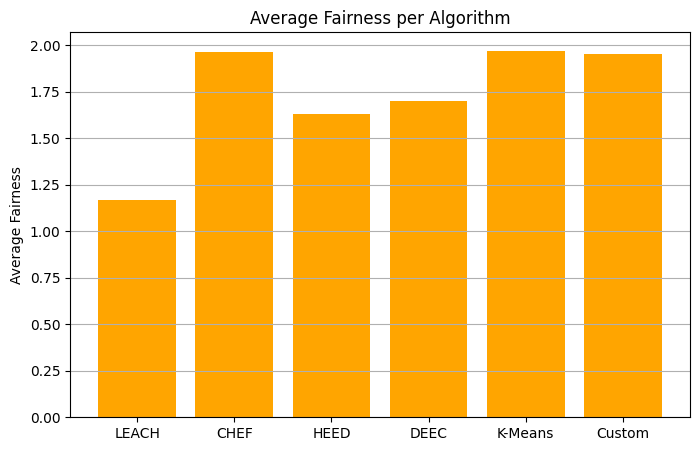

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Example: using the earlier results summary
summary = []

for algo, file in files.items():
    df = pd.read_csv(file)
    first_death = df[df["Dead"] > 0]["Round"].min()
    all_dead = df[df["Dead"] >= 20]["Round"].min()
    avg_ch = df["CHs"].mean()
    avg_fairness = df["Fairness"].mean()
    avg_energy = df["AvgEnergy"].mean()
    summary.append({
        "Algorithm": algo,
        "First Node Death": int(first_death) if pd.notnull(first_death) else "-",
        "All Nodes Dead": int(all_dead) if pd.notnull(all_dead) else "-",
        "Avg. Cluster Heads": round(avg_ch, 2),
        "Avg. Fairness": round(avg_fairness, 2),
        "Avg. Energy": round(avg_energy, 3)
    })
results_df = pd.DataFrame(summary)
print(results_df)

# 1. First Node Death Bar Graph
plt.figure(figsize=(8,5))
plt.bar(results_df["Algorithm"], results_df["First Node Death"], color='teal')
plt.ylabel('First Node Death (Round)')
plt.title('First Node Death for Each Algorithm')
plt.grid(axis='y')
plt.show()

# 2. All Nodes Dead Bar Graph
plt.figure(figsize=(8,5))
plt.bar(results_df["Algorithm"], results_df["All Nodes Dead"], color='tomato')
plt.ylabel('All Nodes Dead (Round)')
plt.title('Network Lifetime (All Nodes Dead) for Each Algorithm')
plt.grid(axis='y')
plt.show()

# 3. Average Cluster Heads
plt.figure(figsize=(8,5))
plt.bar(results_df["Algorithm"], results_df["Avg. Cluster Heads"], color='royalblue')
plt.ylabel('Avg. Cluster Heads per Round')
plt.title('Average Cluster Heads per Algorithm')
plt.grid(axis='y')
plt.show()

# 4. Average Fairness
plt.figure(figsize=(8,5))
plt.bar(results_df["Algorithm"], results_df["Avg. Fairness"], color='orange')
plt.ylabel('Average Fairness')
plt.title('Average Fairness per Algorithm')
plt.grid(axis='y')
plt.show()


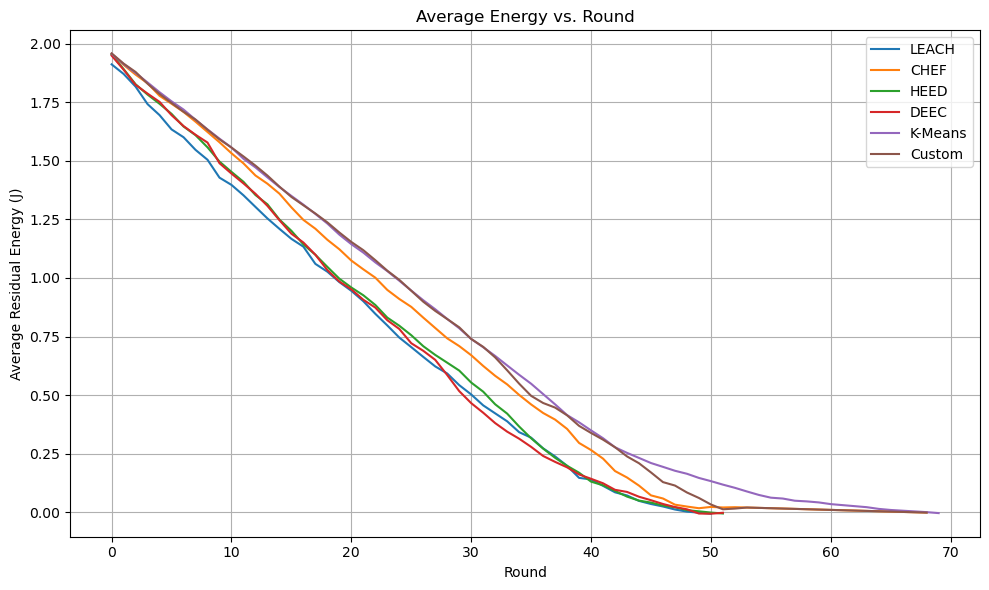

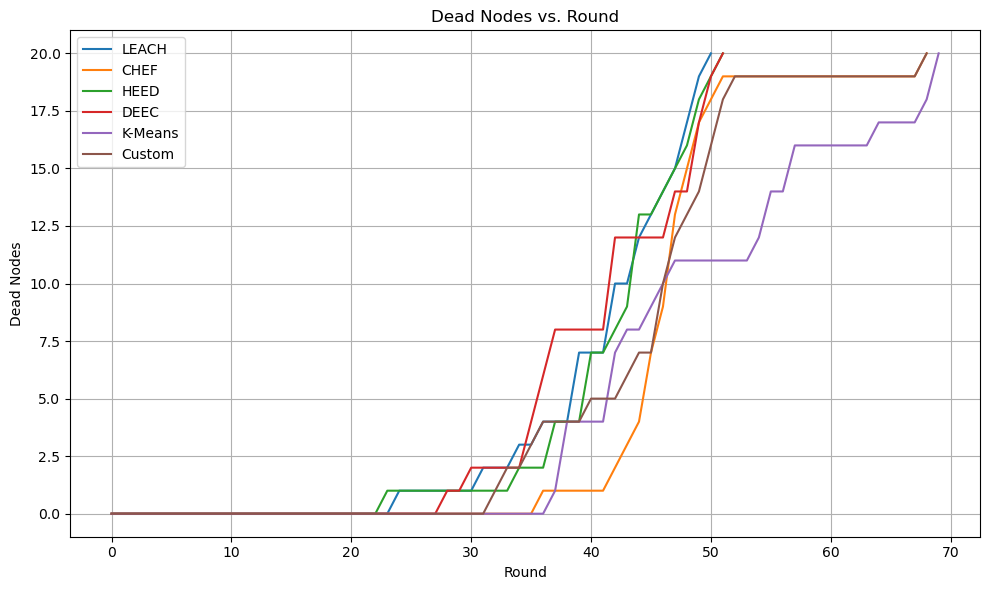

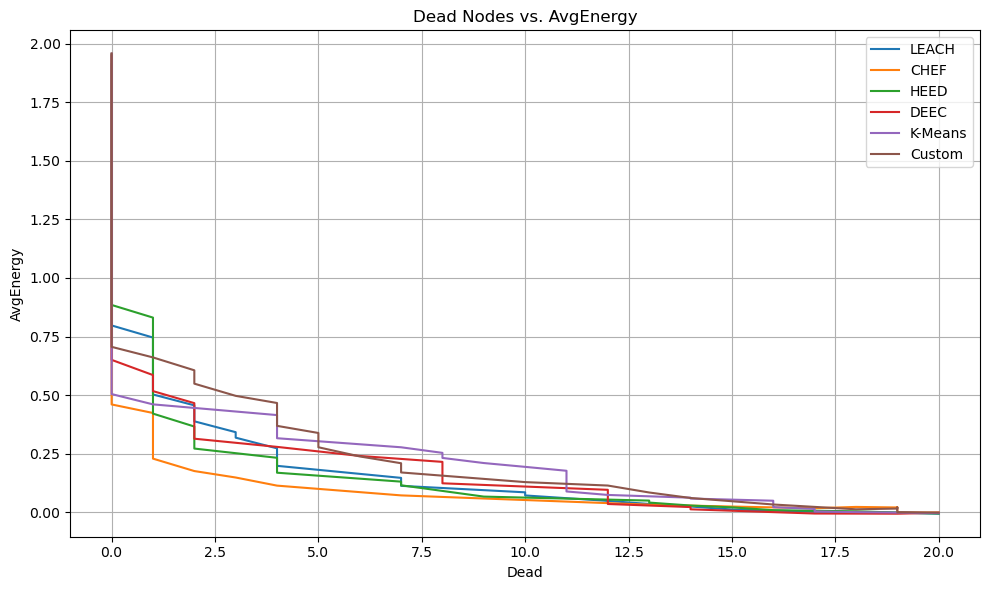

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

algos = ['LEACH', 'CHEF', 'HEED', 'DEEC', 'K-Means', 'Custom']
files = {
    'LEACH': 'leach_log.csv',
    'CHEF': 'chef_log.csv',
    'HEED': 'heed_log.csv',
    'DEEC': 'deec_log.csv',
    'K-Means': 'k-means_log.csv',
    'Custom': 'custom_log.csv'
}
dfs = {algo: pd.read_csv(files[algo]) for algo in algos}

plt.figure(figsize=(10,6))
for algo in algos:
    plt.plot(dfs[algo]['Round'], dfs[algo]['AvgEnergy'], label=f'{algo}')
plt.xlabel('Round')
plt.ylabel('Average Residual Energy (J)')
plt.title('Average Energy vs. Round')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
for algo in algos:
    plt.plot(dfs[algo]['Round'], dfs[algo]['Dead'], label=f'{algo}')
plt.xlabel('Round')
plt.ylabel('Dead Nodes')
plt.title('Dead Nodes vs. Round')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
for algo in algos:
    plt.plot(dfs[algo]['Dead'], dfs[algo]['AvgEnergy'], label=f'{algo}')
plt.xlabel('Dead')
plt.ylabel('AvgEnergy')
plt.title('Dead Nodes vs. AvgEnergy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


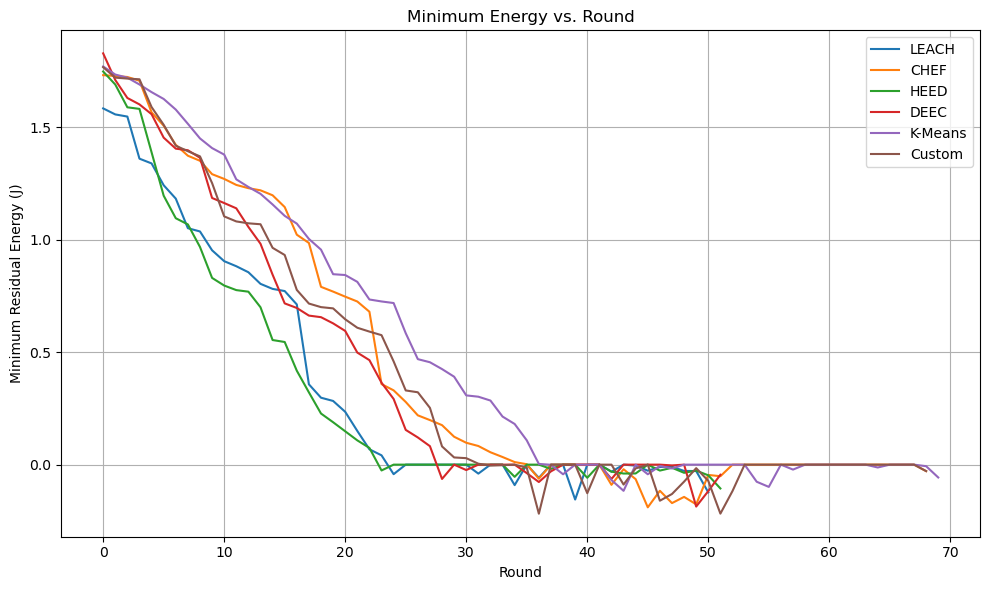

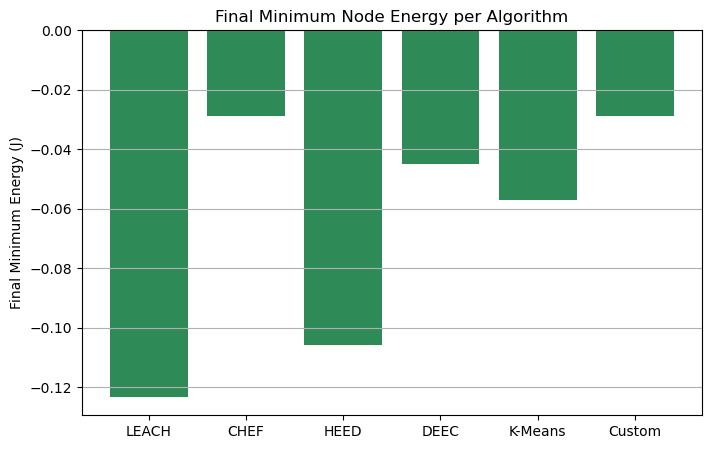

In [11]:
# Line graph (per round)
plt.figure(figsize=(10,6))
for algo in algos:
    plt.plot(dfs[algo]['Round'], dfs[algo]['MinEnergy'], label=algo)
plt.xlabel('Round')
plt.ylabel('Minimum Residual Energy (J)')
plt.title('Minimum Energy vs. Round')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Bar graph (final round)
final_min = [df['MinEnergy'].iloc[-1] for df in dfs.values()]
plt.figure(figsize=(8,5))
plt.bar(algos, final_min, color='seagreen')
plt.ylabel('Final Minimum Energy (J)')
plt.title('Final Minimum Node Energy per Algorithm')
plt.grid(axis='y')
plt.show()


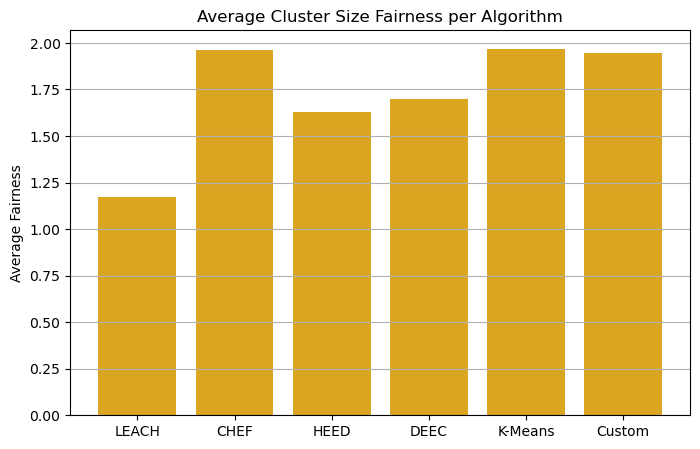

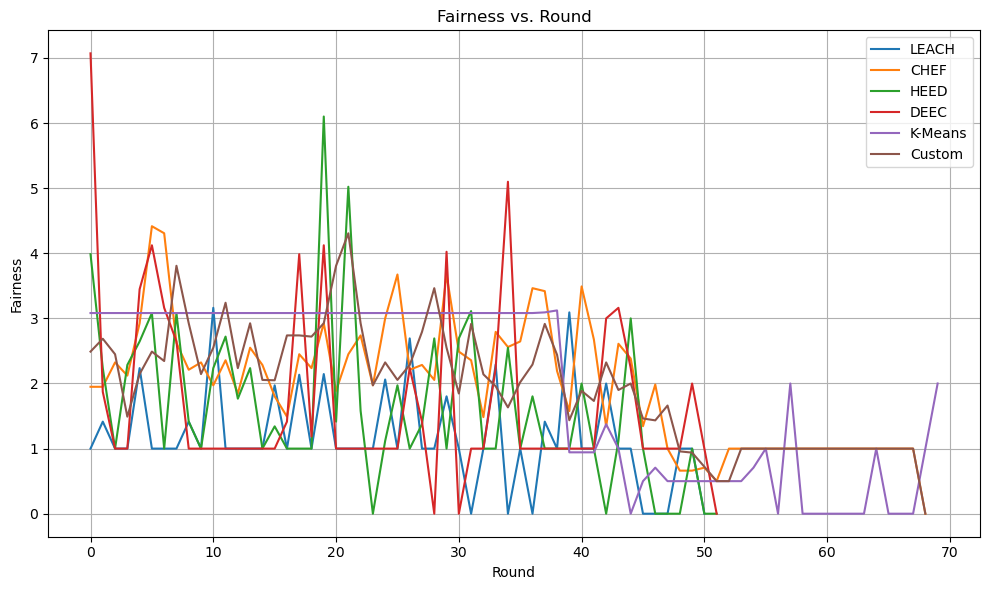

In [13]:
# Average fairness bar graph
avg_fairness = [df['Fairness'].mean() for df in dfs.values()]
plt.figure(figsize=(8,5))
plt.bar(algos, avg_fairness, color='goldenrod')
plt.ylabel('Average Fairness')
plt.title('Average Cluster Size Fairness per Algorithm')
plt.grid(axis='y')
plt.show()

# Line graph (trend)
plt.figure(figsize=(10,6))
for algo in algos:
    plt.plot(dfs[algo]['Round'], dfs[algo]['Fairness'], label=algo)
plt.xlabel('Round')
plt.ylabel('Fairness')
plt.title('Fairness vs. Round')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
